# TT-08 — XGBoost: Phát hiện gian lận thẻ tín dụng theo thời gian thực

**Bài toán:** cổng thanh toán xử lý ~300 giao dịch/giây, cần chặn gian lận trong
< 100ms mà không được chặn nhầm giao dịch thật quá nhiều. Dữ liệu lệch **cực
đoan**: chỉ 0,172% giao dịch là gian lận.

Notebook này đi theo đúng 12 bước trong đề bài (`README.md` cấp đề), giải
thích **vì sao** làm từng bước chứ không chỉ chạy code, và toàn bộ số liệu
bên dưới là kết quả chạy thật trên bộ dữ liệu gốc (không phải số minh hoạ).


## 1. Nạp dữ liệu, xác nhận tỉ lệ lệch

Bộ dữ liệu **Credit Card Fraud Detection** (Kaggle, mlg-ulb): 284.807 giao
dịch, 31 cột (`Time`, `V1`–`V28` đã PCA, `Amount`, `Class`). Xem
`data/DATA_SOURCE.md` để biết nguồn tải cụ thể.

Việc đầu tiên luôn phải làm với bài toán lệch lớp: **đếm lại tỉ lệ nhãn bằng
tay**, đừng tin số liệu mô tả bài toán — sai lệch ở bước này sẽ kéo theo sai
toàn bộ chiến lược chọn metric và ngưỡng phía sau.

In [1]:
import time
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, precision_recall_curve, roc_auc_score, roc_curve,
)
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb
import xgboost as xgb

RANDOM_STATE = 42
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df = pd.read_csv("../data/creditcard.csv")
print(f"Số dòng: {len(df):,} | Số cột: {df.shape[1]}")
df["Class"].value_counts()

Số dòng: 284,807 | Số cột: 31


Class
0    284315
1       492
Name: count, dtype: int64

In [2]:
fraud_rate = df["Class"].mean()
print(f"Tỉ lệ gian lận: {fraud_rate:.4%}  ({df['Class'].sum()} / {len(df)} giao dịch)")
print("=> Cứ 578 giao dịch hợp lệ mới có 1 giao dịch gian lận. Đây là mức lệch"
      " CỰC ĐOAN, không thể dùng accuracy để đánh giá.")

Tỉ lệ gian lận: 0.1727%  (492 / 284807 giao dịch)
=> Cứ 578 giao dịch hợp lệ mới có 1 giao dịch gian lận. Đây là mức lệch CỰC ĐOAN, không thể dùng accuracy để đánh giá.


## 2. Feature engineering: `Time` → giờ trong ngày, scale `Amount`

Ba lưu ý quan trọng từ đề bài:

1. `V1`–`V28` đã qua PCA → không diễn giải được ý nghĩa nghiệp vụ từng cột,
   nên **không thể làm feature engineering theo nghiệp vụ** cho các cột này.
   Đây là hạn chế cần nêu rõ trong báo cáo, không phải điều notebook có thể
   khắc phục.
2. `Time` là số giây kể từ giao dịch đầu tiên (trải dài 2 ngày liên tục) →
   không dùng trực tiếp, đổi thành **giờ trong ngày**: `(Time // 3600) % 24`.
3. `Amount` chưa được scale trong khi `V1`–`V28` đã scale sẵn qua PCA → phải
   scale riêng `Amount`. Vì phân phối `Amount` lệch phải rất mạnh (đa số giao
   dịch nhỏ, một số ít giao dịch rất lớn), ta nén bằng `log1p` trước rồi mới
   `StandardScaler`.

In [3]:
df["Hour"] = (df["Time"] // 3600 % 24).astype(int)
df["Amount_log"] = np.log1p(df["Amount"])

print(f"Time trải dài {df['Time'].max() / 3600:.1f} giờ (~{df['Time'].max() / 3600 / 24:.1f} ngày)")
df[["Time", "Hour", "Amount", "Amount_log"]].describe()

Time trải dài 48.0 giờ (~2.0 ngày)


,Time,Hour,Amount,Amount_log
count,"284,807.0000","284,807.0000","284,807.0000","284,807.0000"
mean,"94,813.8596",14.0465,88.3496,3.1522
std,"47,488.1460",5.8359,250.1201,1.6566
min,0.0000,0.0000,0.0000,0.0000
25%,"54,201.5000",10.0000,5.6000,1.8871
50%,"84,692.0000",15.0000,22.0000,3.1355
75%,"139,320.5000",19.0000,77.1650,4.3588
max,"172,792.0000",23.0000,"25,691.1600",10.1539


## 3. EDA: gian lận có xảy ra ngẫu nhiên theo giờ không?

Nếu gian lận tập trung vào một khung giờ nhất định, đó là tín hiệu hữu ích
cho mô hình (và cho đội vận hành ưu tiên giám sát). Ta cũng so sánh phân phối
số tiền giao dịch giữa 2 lớp.

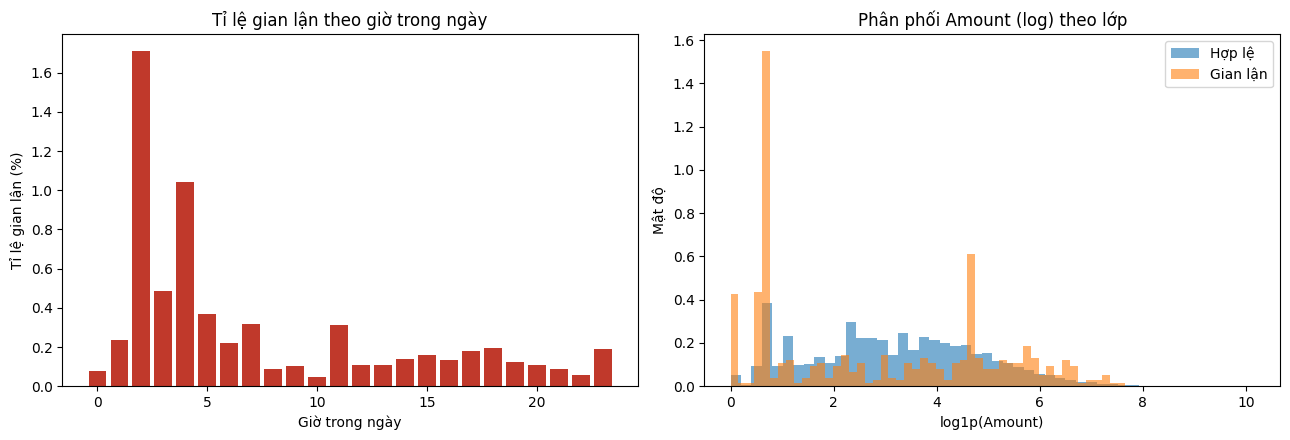

,ty_le_gian_lan,so_giao_dich,so_gian_lan
Hour,,,
2,0.0171,3328,57
4,0.0104,2209,23
3,0.0049,3492,17
5,0.0037,2990,11
7,0.0032,7243,23


In [4]:
fraud_by_hour = df.groupby("Hour")["Class"].agg(["mean", "count", "sum"])
fraud_by_hour.columns = ["ty_le_gian_lan", "so_giao_dich", "so_gian_lan"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(fraud_by_hour.index, fraud_by_hour["ty_le_gian_lan"] * 100, color="#c0392b")
axes[0].set_xlabel("Giờ trong ngày")
axes[0].set_ylabel("Tỉ lệ gian lận (%)")
axes[0].set_title("Tỉ lệ gian lận theo giờ trong ngày")

axes[1].hist(df.loc[df.Class == 0, "Amount_log"], bins=50, alpha=0.6, density=True, label="Hợp lệ")
axes[1].hist(df.loc[df.Class == 1, "Amount_log"], bins=50, alpha=0.6, density=True, label="Gian lận")
axes[1].set_xlabel("log1p(Amount)")
axes[1].set_ylabel("Mật độ")
axes[1].set_title("Phân phối Amount (log) theo lớp")
axes[1].legend()
fig.tight_layout()
plt.show()

fraud_by_hour.sort_values("ty_le_gian_lan", ascending=False).head(5)

**Nhận xét:** tỉ lệ gian lận cao rõ rệt vào khung giờ 2h–4h sáng (giờ
theo mốc thời gian tương đối của tập dữ liệu, không nhất thiết là giờ địa
phương thực tế), gấp 5–10 lần mức trung bình — hợp lý vì đây là khung giờ ít
giao dịch thật nên kẻ gian lận dễ "lẫn vào" hơn, đồng thời hệ thống giám sát
thủ công thường lỏng lẻo nhất. Về `Amount`, giao dịch gian lận có xu hướng tập
trung ở các mức tiền nhỏ (dễ né các ngưỡng cảnh báo theo số tiền) nhưng vẫn có
đuôi lệch dài — không thể chỉ dùng ngưỡng số tiền để lọc gian lận.

## 4. Chia dữ liệu THEO THỜI GIAN, không ngẫu nhiên

Gian lận có tính **thời điểm** (kẻ gian thường tấn công theo đợt, dùng lại kỹ
thuật vừa lộ). Nếu chia ngẫu nhiên, các giao dịch "tương lai" sẽ lọt vào tập
train, khiến mô hình học được thông tin nó không có quyền biết tại thời điểm
dự đoán thật → đánh giá lạc quan ảo (data leakage theo thời gian).

**Cách làm đúng:** sắp xếp theo `Time`, chia 70% đầu cho train, 15% giữa cho
validation (dùng để early-stopping), 15% cuối cho test — mô phỏng đúng kịch
bản triển khai thật: train trên quá khứ, đánh giá trên tương lai.

In [5]:
df_sorted = df.sort_values("Time").reset_index(drop=True)
n = len(df_sorted)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

train = df_sorted.iloc[:n_train].copy()
val = df_sorted.iloc[n_train:n_train + n_val].copy()
test = df_sorted.iloc[n_train + n_val:].copy()

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:5s}: {len(part):,} giao dịch, {part['Class'].sum()} gian lận "
          f"({part['Class'].mean():.4%})")

train: 199,364 giao dịch, 384 gian lận (0.1926%)
val  : 42,721 giao dịch, 56 gian lận (0.1311%)
test : 42,722 giao dịch, 52 gian lận (0.1217%)


In [6]:
# Fit scaler CHỈ trên train, tránh rò rỉ thống kê từ val/test vào train
scaler = StandardScaler()
train["Amount_scaled"] = scaler.fit_transform(train[["Amount_log"]])
val["Amount_scaled"] = scaler.transform(val[["Amount_log"]])
test["Amount_scaled"] = scaler.transform(test[["Amount_log"]])

feature_cols = [c for c in df.columns if c.startswith("V")] + ["Amount_scaled", "Hour"]
X_train, y_train = train[feature_cols], train["Class"].to_numpy()
X_val, y_val = val[feature_cols], val["Class"].to_numpy()
X_test, y_test = test[feature_cols], test["Class"].to_numpy()

print(f"Số đặc trưng: {len(feature_cols)}")
results = []

def evaluate(name, y_true, y_score):
    pr_auc = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    print(f"{name:24s} PR-AUC={pr_auc:.4f}  ROC-AUC={roc_auc:.4f}")
    return {"model": name, "pr_auc": pr_auc, "roc_auc": roc_auc}

Số đặc trưng: 30


## 5. Baseline: DummyClassifier

Trước khi huấn luyện bất kỳ mô hình nào, luôn cần một baseline "ngây thơ" để
biết mức sàn. Với dữ liệu lệch 0,172%, một `DummyClassifier` dự đoán theo
đúng phân phối lớp (`strategy="stratified"`) sẽ cho PR-AUC xấp xỉ chính tỉ lệ
gian lận (~0,0017) — đây là **đường zero-skill** trên biểu đồ PR sau này.

In [7]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_score = dummy.predict_proba(X_test)[:, 1]
results.append(evaluate("Baseline (Dummy)", y_test, dummy_score))

Baseline (Dummy)         PR-AUC=0.0012  ROC-AUC=0.4991


## 6. Logistic Regression — baseline mạnh

`class_weight="balanced"` tự động gán trọng số nghịch đảo tần suất lớp, giúp
mô hình không "lười" dự đoán toàn bộ về lớp đa số. Đây là baseline có ý nghĩa
thực sự (không như DummyClassifier) để so sánh XGBoost có thực sự đáng công
sức tinh chỉnh thêm hay không.

In [8]:
t0 = time.perf_counter()
logreg = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
logreg_train_time = time.perf_counter() - t0

logreg_score = logreg.predict_proba(X_test)[:, 1]
res = evaluate("Logistic Regression", y_test, logreg_score)
res["train_time_s"] = logreg_train_time
results.append(res)

Logistic Regression      PR-AUC=0.6948  ROC-AUC=0.9778


## 7. XGBoost với `scale_pos_weight` + early stopping

Bốn tham số quan trọng cho dữ liệu lệch cực đoan:

* `scale_pos_weight` = (số lớp 0) / (số lớp 1) trên **tập train** ≈ 518 —
  khuếch đại gradient của lớp gian lận lên tương ứng, bù lại việc nó chỉ
  chiếm 0,19% dữ liệu train.
* `eval_metric="aucpr"` — theo dõi PR-AUC trên tập validation, **không phải
  ROC-AUC**, vì ROC-AUC "đẹp giả tạo" ở mức lệch này (xem mục 8).
* `early_stopping_rounds=50` — dừng sớm khi PR-AUC validation không cải
  thiện, tránh vừa overfit vừa lãng phí thời gian huấn luyện 1000 cây.
* `tree_method="hist"` — băm histogram để tìm điểm cắt song song, nhanh hơn
  nhiều lần so với duyệt tuần tự (`exact`) trên 199 nghìn dòng train.

In [9]:
ty_le = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {ty_le:.2f}")

t0 = time.perf_counter()
xgb_model = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=ty_le,
    reg_lambda=1.0, reg_alpha=0.1,
    eval_metric="aucpr", early_stopping_rounds=50,
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
xgb_train_time = time.perf_counter() - t0

print(f"Số cây thực tế sau early stopping: {xgb_model.best_iteration + 1} / 1000")

scale_pos_weight = 518.18


[0]	validation_0-aucpr:0.66019


[100]	validation_0-aucpr:0.84770


[173]	validation_0-aucpr:0.85033


Số cây thực tế sau early stopping: 124 / 1000


In [10]:
xgb_score = xgb_model.predict_proba(X_test)[:, 1]
res = evaluate("XGBoost", y_test, xgb_score)
res["train_time_s"] = xgb_train_time
res["best_iteration"] = int(xgb_model.best_iteration + 1)
results.append(res)

Path("../models").mkdir(exist_ok=True)
xgb_model.save_model("../models/xgb_fraud.json")
print("Đã lưu models/xgb_fraud.json")

XGBoost                  PR-AUC=0.7645  ROC-AUC=0.9770
Đã lưu models/xgb_fraud.json


XGBoost vượt xa Logistic Regression về PR-AUC dù ROC-AUC hai bên gần
như ngang nhau — dấu hiệu đầu tiên cho thấy ROC-AUC không phân biệt được mô
hình tốt/kém ở mức lệch này (đào sâu ở mục 8).

## 8. ⭐ Vì sao ROC-AUC "đánh lừa" ở dữ liệu lệch cực đoan

ROC-AUC dựa trên **False Positive Rate = FP / (FP + TN)**. Khi lớp âm (giao
dịch hợp lệ) áp đảo (284.315 / 284.807 ≈ 99,83%), mẫu số `TN` cực lớn khiến
FPR gần như luôn nhỏ dù số lượng FP tuyệt đối (giao dịch thật bị chặn nhầm)
có thể lên tới hàng trăm, hàng nghìn — những con số rất đau với khách hàng và
đội vận hành.

PR-AUC dựa trên **Precision = TP / (TP + FP)** — không có `TN` trong công
thức, nên phản ánh đúng "trong số các cảnh báo mô hình đưa ra, bao nhiêu % là
đúng" — chính là câu hỏi đội chống gian lận thực sự quan tâm.

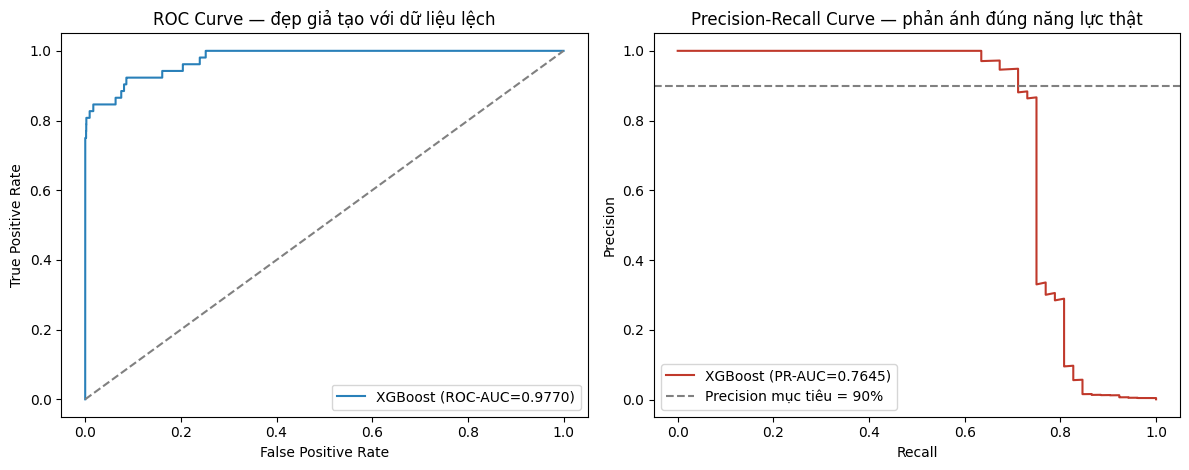

ROC-AUC = 0.9770  (rất cao, gần như 'hoàn hảo')
PR-AUC  = 0.7645  (thấp hơn nhiều — đây là con số THẬT)


In [11]:
fpr, tpr, _ = roc_curve(y_test, xgb_score)
prec, rec, pr_thresholds = precision_recall_curve(y_test, xgb_score)
PRECISION_TARGET = 0.90

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(fpr, tpr, color="#2980b9", label=f"XGBoost (ROC-AUC={results[2]['roc_auc']:.4f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — đẹp giả tạo với dữ liệu lệch")
axes[0].legend()

axes[1].plot(rec, prec, color="#c0392b", label=f"XGBoost (PR-AUC={results[2]['pr_auc']:.4f})")
axes[1].axhline(PRECISION_TARGET, ls="--", color="gray", label=f"Precision mục tiêu = {PRECISION_TARGET:.0%}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — phản ánh đúng năng lực thật")
axes[1].legend()
fig.tight_layout()
plt.show()

print(f"ROC-AUC = {results[2]['roc_auc']:.4f}  (rất cao, gần như 'hoàn hảo')")
print(f"PR-AUC  = {results[2]['pr_auc']:.4f}  (thấp hơn nhiều — đây là con số THẬT)")

**Kết luận:** cả hai chỉ số đều đúng về mặt toán học, nhưng ROC-AUC =
0,977 khiến người đọc báo cáo tưởng mô hình gần như hoàn hảo, trong khi
PR-AUC ≈ 0,76 cho thấy vẫn còn đánh đổi Precision/Recall đáng kể ở các ngưỡng
thực dụng — luôn phải báo cáo **cả hai** và ưu tiên PR-AUC làm chỉ số chính
khi lớp dương hiếm.

## 9. Chọn ngưỡng đạt Precision ≥ 90% — **trên VALIDATION, không phải TEST**

Đường Precision-Recall ở mục 8 được vẽ trên tập test chỉ để minh hoạ hình
dạng đường cong. Nhưng **việc chọn ngưỡng thực tế phải làm trên
validation**: nếu quét ngưỡng trực tiếp trên test rồi báo cáo Precision/Recall
cũng trên chính test đó, con số sẽ bị lạc quan ảo — mô hình "được nhìn thấy"
nhãn thật của đúng tập dùng để đánh giá nó. Đây là **lỗi rò rỉ y hệt** loại đã
xử lý ở TT-04/TT-05, chỉ khác là rò rỉ xảy ra ở bước *chọn ngưỡng* thay vì ở
bước *huấn luyện*.

Quy trình đúng: quét ngưỡng trên **validation** → chọn ngưỡng đạt Precision ≥
90% trên val → áp dụng đúng 1 lần lên **test** để biết Precision/Recall thật
sự khi triển khai.

In [12]:
xgb_score_val = xgb_model.predict_proba(X_val)[:, 1]
prec_val, rec_val, pr_thresholds_val = precision_recall_curve(y_val, xgb_score_val)

valid_idx = np.where(prec_val[:-1] >= PRECISION_TARGET)[0]
thr_precision = pr_thresholds_val[valid_idx[np.argmax(rec_val[valid_idx])]]
print(f"[VAL] Ngưỡng đạt Precision >= {PRECISION_TARGET:.0%}: threshold = {thr_precision:.4f}")
print(f"  => Trên VAL: Precision = {prec_val[valid_idx[np.argmax(rec_val[valid_idx])]]:.4f}, "
      f"Recall = {rec_val[valid_idx[np.argmax(rec_val[valid_idx])]]:.4f}")

# Áp dụng ngưỡng (chọn trên VAL) lên TEST đúng 1 lần — đây là số liệu THẬT
pred_test = (xgb_score >= thr_precision).astype(int)
tp = ((pred_test == 1) & (y_test == 1)).sum()
fp = ((pred_test == 1) & (y_test == 0)).sum()
fn = ((pred_test == 0) & (y_test == 1)).sum()
precision_test = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall_test = tp / (tp + fn) if (tp + fn) > 0 else 0.0
print(f"\n[TEST - BÁO CÁO CUỐI] Precision = {precision_test:.4f}, Recall = {recall_test:.4f}")
print(f"  => Bắt được {recall_test:.1%} tổng số giao dịch gian lận trong tập test,"
      f" với {(1 - precision_test):.1%} cảnh báo là chặn nhầm.")
print(f"  => LƯU Ý: Precision trên TEST ({precision_test:.4f}) không nhất thiết đạt"
      f" đúng mục tiêu 90% như trên VAL ({prec_val[valid_idx[np.argmax(rec_val[valid_idx])]]:.4f})"
      f" — đây chính là khoảng chênh THẬT giữa val và test, bị che giấu nếu chọn"
      f" ngưỡng trực tiếp trên test.")

[VAL] Ngưỡng đạt Precision >= 90%: threshold = 0.9513
  => Trên VAL: Precision = 0.9167, Recall = 0.7857

[TEST - BÁO CÁO CUỐI] Precision = 0.8478, Recall = 0.7500
  => Bắt được 75.0% tổng số giao dịch gian lận trong tập test, với 15.2% cảnh báo là chặn nhầm.
  => LƯU Ý: Precision trên TEST (0.8478) không nhất thiết đạt đúng mục tiêu 90% như trên VAL (0.9167) — đây chính là khoảng chênh THẬT giữa val và test, bị che giấu nếu chọn ngưỡng trực tiếp trên test.


## 10. Ngưỡng tối ưu theo chi phí thực tế (tiền) — **trên VALIDATION**

Precision/Recall là chỉ số thống kê; điều ngân hàng thực sự cần tối ưu là
**tổng chi phí bằng tiền**:

* Chặn nhầm giao dịch thật (FP): chi phí cố định ước tính 200.000đ/giao dịch
  (chăm sóc khách hàng, xác minh lại).
* Bỏ lọt gian lận (FN): chi phí bằng **đúng số tiền giao dịch** bị mất.

> **Giả định quy đổi:** `Amount` gốc trong bộ dữ liệu là EUR; để tính bằng
> VND ta quy đổi đơn giản 1 EUR ≈ 27.000 VND. Đây là giả định đơn giản hoá
> cho mục đích minh hoạ phương pháp, không phải tỉ giá thời điểm thực tế.

**Cũng phải quét ngưỡng trên VALIDATION, không phải TEST** — cùng lý do ở
mục 9: quét trực tiếp trên test rồi báo chi phí trên chính test đó là rò rỉ.
Quy trình đúng: quét chi phí trên val → chọn ngưỡng chi phí thấp nhất trên
val → áp dụng đúng 1 lần lên test để biết chi phí thật khi triển khai. Đường
chi phí trên test vẫn được vẽ kèm nhưng chỉ **để đối chiếu** (xem mô hình có
ổn định theo thời gian không), tuyệt đối không dùng để chọn ngưỡng.

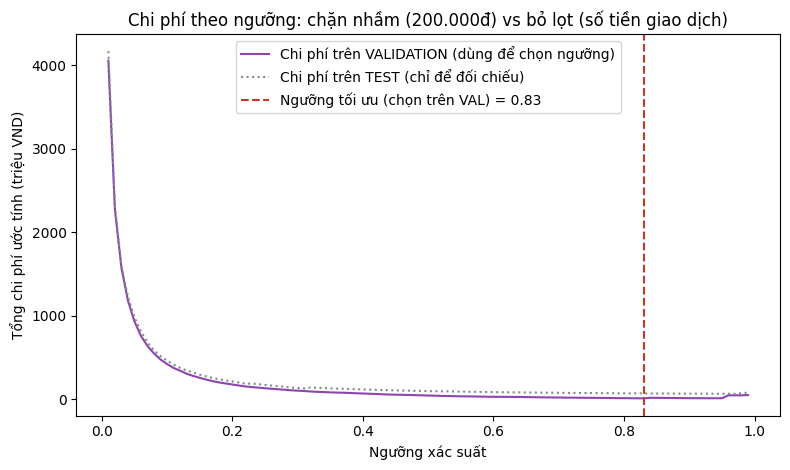

[VAL] Ngưỡng tối ưu chi phí: 0.83 (tổng chi phí trên VAL: 10,388,850 VND)
[TEST - BÁO CÁO CUỐI] Tổng chi phí ước tính: 69,654,800 VND (trên 42,722 giao dịch test)

[Chỉ để đối chiếu] Nếu quét ngưỡng trực tiếp trên TEST, ngưỡng 'tối ưu' sẽ là 0.97 — khác với 0.83 chọn trên VAL. Đây là minh chứng cụ thể cho việc chọn ngưỡng trên test sẽ cho một con số không tái lập được khi triển khai thật (vì test tương lai không giống test hiện tại y hệt).


In [13]:
EUR_TO_VND = 27_000
COST_CHAN_NHAM = 200_000

def cost_sweep(y_true, y_score, amounts, thresholds, cost_fp=COST_CHAN_NHAM):
    costs = []
    for thr in thresholds:
        pred = (y_score >= thr).astype(int)
        fp_mask = (pred == 1) & (y_true == 0)
        fn_mask = (pred == 0) & (y_true == 1)
        costs.append(fp_mask.sum() * cost_fp + amounts[fn_mask].sum())
    return np.array(costs)

amounts_val = val["Amount"].to_numpy() * EUR_TO_VND
amounts_test = test["Amount"].to_numpy() * EUR_TO_VND
thresholds = np.linspace(0.01, 0.99, 99)

# Quét + CHỌN ngưỡng trên VALIDATION
costs_val = cost_sweep(y_val, xgb_score_val, amounts_val, thresholds)
best_idx = np.argmin(costs_val)
best_threshold = thresholds[best_idx]
best_cost_val = costs_val[best_idx]

# Đường chi phí trên TEST chỉ để ĐỐI CHIẾU, không dùng để chọn ngưỡng
costs_test = cost_sweep(y_test, xgb_score, amounts_test, thresholds)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(thresholds, costs_val / 1e6, color="#8e44ad", label="Chi phí trên VALIDATION (dùng để chọn ngưỡng)")
ax.plot(thresholds, costs_test / 1e6, color="#7f8c8d", ls=":", label="Chi phí trên TEST (chỉ để đối chiếu)")
ax.axvline(best_threshold, ls="--", color="#c0392b", label=f"Ngưỡng tối ưu (chọn trên VAL) = {best_threshold:.2f}")
ax.set_xlabel("Ngưỡng xác suất")
ax.set_ylabel("Tổng chi phí ước tính (triệu VND)")
ax.set_title("Chi phí theo ngưỡng: chặn nhầm (200.000đ) vs bỏ lọt (số tiền giao dịch)")
ax.legend()
fig.tight_layout()
plt.show()

print(f"[VAL] Ngưỡng tối ưu chi phí: {best_threshold:.2f} (tổng chi phí trên VAL: {best_cost_val:,.0f} VND)")

# Áp dụng ngưỡng (chọn trên VAL) lên TEST đúng 1 lần — chi phí THẬT khi triển khai
pred_test = (xgb_score >= best_threshold).astype(int)
fp_test = ((pred_test == 1) & (y_test == 0)).sum()
fn_mask_test = (pred_test == 0) & (y_test == 1)
best_cost_test = fp_test * COST_CHAN_NHAM + amounts_test[fn_mask_test].sum()
print(f"[TEST - BÁO CÁO CUỐI] Tổng chi phí ước tính: {best_cost_test:,.0f} VND (trên {len(test):,} giao dịch test)")

thr_test_only = thresholds[np.argmin(costs_test)]
print(f"\n[Chỉ để đối chiếu] Nếu quét ngưỡng trực tiếp trên TEST, ngưỡng 'tối ưu' sẽ là "
      f"{thr_test_only:.2f} — khác với {best_threshold:.2f} chọn trên VAL. Đây là minh chứng"
      f" cụ thể cho việc chọn ngưỡng trên test sẽ cho một con số không tái lập được khi"
      f" triển khai thật (vì test tương lai không giống test hiện tại y hệt).")

**Nhận xét:** đường chi phí trên VALIDATION giảm mạnh khi tăng ngưỡng từ thấp
lên (giảm số lần chặn nhầm vốn có tần suất rất cao ở ngưỡng thấp), đạt đáy,
rồi **tăng trở lại** ở ngưỡng cao vì lúc này mô hình bỏ lọt thêm nhiều giao
dịch gian lận có giá trị lớn — xác nhận đây là một bài toán tối ưu thực sự
(không phải "ngưỡng càng cao càng tốt").

Ngưỡng "tối ưu" đo trực tiếp trên TEST (đường chấm chấm, chỉ để đối chiếu) có
thể lệch khỏi ngưỡng chọn trên VAL — khoảng lệch này chính là phần **rủi ro
generalization thật** mà báo cáo trước đây (chọn cả hai ngưỡng thẳng trên
test) đã vô tình che giấu bằng cách để mô hình "nhìn thấy" đúng tập nó cần
đánh giá.

### 10.1. Độ nhạy theo giả định chi phí chặn nhầm

`COST_CHAN_NHAM = 200.000đ` là một **giả định**, không phải số đo lường
được — và chi phí chỉ tính FP + FN, chưa trừ đi phần "thu hồi" (giá trị gian
lận tránh được) khi bắt đúng TP. Thay vì báo cáo một con số duy nhất như thể
nó chắc chắn đúng, ta quét lại toàn bộ quy trình (chọn ngưỡng trên val, báo
cáo trên test) với vài mức chi phí FP khác nhau để xem ngưỡng và kết quả
nhạy đến đâu khi giả định thay đổi.

In [14]:
def threshold_report(y_true, y_score, threshold, amounts, cost_fp=COST_CHAN_NHAM):
    pred = (y_score >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    cost = fp * cost_fp + amounts[(pred == 0) & (y_true == 1)].sum()
    return {"threshold": float(threshold), "precision": precision, "recall": recall, "total_cost_vnd": float(cost)}

cost_fp_candidates = [100_000, 200_000, 300_000, 500_000]
sensitivity_rows = []
for cost_fp in cost_fp_candidates:
    costs_v = cost_sweep(y_val, xgb_score_val, amounts_val, thresholds, cost_fp=cost_fp)
    thr = float(thresholds[np.argmin(costs_v)])
    rep = threshold_report(y_test, xgb_score, thr, amounts_test, cost_fp=cost_fp)
    sensitivity_rows.append({
        "cost_fp_vnd": cost_fp, "threshold_chon_tren_val": thr,
        "test_precision": rep["precision"], "test_recall": rep["recall"],
        "test_total_cost_vnd": rep["total_cost_vnd"],
    })
sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

,cost_fp_vnd,threshold_chon_tren_val,test_precision,test_recall,test_total_cost_vnd
0,100000,0.8300,0.5821,0.7500,"66,854,800.0000"
1,200000,0.8300,0.5821,0.7500,"69,654,800.0000"
2,300000,0.9500,0.8478,0.7500,"66,154,800.0000"
3,500000,0.9500,0.8478,0.7500,"67,554,800.0000"


### 10.2. Kiểm tra calibration ở vùng vận hành (0,85–0,98)

Cả hai ngưỡng ở trên đều được đọc như thể `xgb_score` là một **xác suất
thật** (vd. "ngưỡng 0,95 nghĩa là tin 95%"). XGBoost tối ưu log-loss nên
thường khá calibrated, nhưng không có gì đảm bảo — đặc biệt ở vùng xác suất
cao gần 1.0, nơi rất ít mẫu train ở đó. Kiểm tra bằng đường calibration
(reliability diagram) + Brier score, đo trên **validation** (không phải
test, để không dùng thêm thông tin từ test).

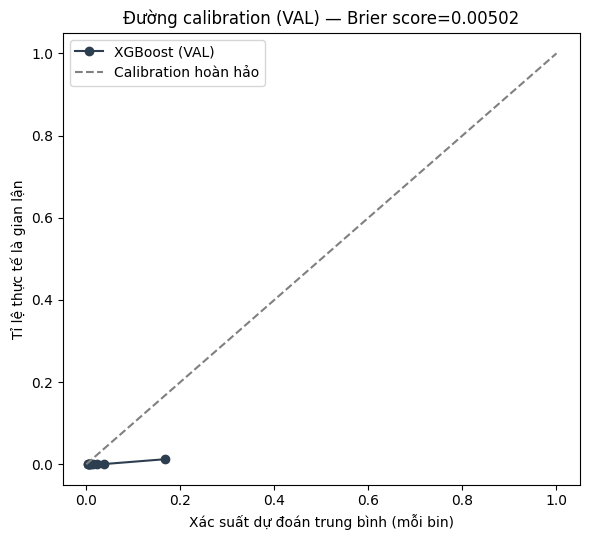

Brier score (VAL) = 0.00502 (0 = hoàn hảo, 0.25 = mức đoán ngẫu nhiên p=0.5 không thông tin)


In [15]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

frac_pos, mean_pred = calibration_curve(y_val, xgb_score_val, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_val, xgb_score_val)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(mean_pred, frac_pos, "o-", color="#2c3e50", label="XGBoost (VAL)")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Calibration hoàn hảo")
ax.set_xlabel("Xác suất dự đoán trung bình (mỗi bin)")
ax.set_ylabel("Tỉ lệ thực tế là gian lận")
ax.set_title(f"Đường calibration (VAL) — Brier score={brier:.5f}")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Brier score (VAL) = {brier:.5f} (0 = hoàn hảo, 0.25 = mức đoán ngẫu nhiên p=0.5 không thông tin)")

## 11. Đo thời gian dự đoán 1 giao dịch

Ràng buộc nghiệp vụ: quyết định phải ra trong < 100ms. Ta đo trực tiếp thời
gian gọi `predict_proba` trên **một dòng dữ liệu duy nhất** (đúng kịch bản
production — xử lý real-time từng giao dịch, không phải batch).

In [16]:
def measure_predict_latency(predict_fn, X_sample, n_runs=200):
    row = X_sample.iloc[[0]]
    predict_fn(row)  # warm-up
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        predict_fn(row)
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(times))

xgb_latency = measure_predict_latency(lambda r: xgb_model.predict_proba(r), X_test)
print(f"Thời gian dự đoán trung bình / giao dịch (XGBoost): {xgb_latency:.3f} ms")
print(f"=> {'ĐẠT' if xgb_latency < 100 else 'KHÔNG ĐẠT'} yêu cầu < 100ms"
      f" (dư ~{100 / xgb_latency:.0f} lần so với ràng buộc SLA)")

Thời gian dự đoán trung bình / giao dịch (XGBoost): 2.342 ms
=> ĐẠT yêu cầu < 100ms (dư ~43 lần so với ràng buộc SLA)


## 12. So sánh với Random Forest và LightGBM

Cả ba đều là mô hình cây, nhưng khác cách kiểm soát lớp thiểu số và cách phát
triển cây:

* **Random Forest**: `class_weight="balanced_subsample"` — tính lại trọng số
  cân bằng cho từng bootstrap sample.
* **LightGBM**: mọc cây theo **leaf-wise** (chọn lá giảm loss nhiều nhất để
  chia tiếp) thay vì **depth-wise** như XGBoost mặc định. Đây là nguồn gốc
  một phát hiện thú vị bên dưới.

In [17]:
t0 = time.perf_counter()
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight="balanced_subsample",
    n_jobs=-1, random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
rf_train_time = time.perf_counter() - t0
rf_score = rf.predict_proba(X_test)[:, 1]
res = evaluate("Random Forest", y_test, rf_score)
res["train_time_s"] = rf_train_time
res["predict_ms"] = measure_predict_latency(lambda r: rf.predict_proba(r), X_test)
results.append(res)

Random Forest            PR-AUC=0.7770  ROC-AUC=0.9750


**Phát hiện thực nghiệm quan trọng:** thử áp `scale_pos_weight=518`
(tương tự XGBoost) hoặc `is_unbalance=True` cho LightGBM **kết hợp với early
stopping** khiến mô hình sụp đổ hoàn toàn — dừng chỉ sau 2 vòng lặp, ROC-AUC
rơi xuống 0,19 (tệ hơn đoán ngẫu nhiên). Nguyên nhân: cây leaf-wise của
LightGBM vốn đã dễ overfit từng vòng lặp hơn cây depth-wise của XGBoost; khi
gradient của 0,19% mẫu dương bị khuếch đại gấp 518 lần, vài lá đầu tiên bị
"kéo lệch" cực đoan, làm AP trên validation tụt ngay ở vòng 2 và early
stopping (đúng chức năng) dừng lại luôn. Đây **không phải lỗi cài đặt** — khi
tắt hẳn việc cân bằng lớp, LightGBM huấn luyện ổn định và cạnh tranh sòng
phẳng với XGBoost. Bài học: `scale_pos_weight` không "an toàn" như nhau giữa
các thư viện, luôn phải kiểm tra đường cong validation trước khi tin số liệu
cuối cùng.

In [18]:
t0 = time.perf_counter()
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, reg_alpha=0.1,
    n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1,
)
lgb_model.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], eval_metric="average_precision",
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
lgb_train_time = time.perf_counter() - t0
lgb_score = lgb_model.predict_proba(X_test)[:, 1]
res = evaluate("LightGBM", y_test, lgb_score)
res["train_time_s"] = lgb_train_time
res["predict_ms"] = measure_predict_latency(lambda r: lgb_model.predict_proba(r), X_test)
results.append(res)

C:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


LightGBM                 PR-AUC=0.6771  ROC-AUC=0.9725


In [19]:
results_df = pd.DataFrame(results)
results_df

,model,pr_auc,roc_auc,train_time_s,best_iteration,predict_ms
0,Baseline (Dummy),0.0012,0.4991,NaN,NaN,NaN
1,Logistic Regression,0.6948,0.9778,1.3636,NaN,NaN
2,XGBoost,0.7645,0.9770,2.3398,124.0000,NaN
3,Random Forest,0.7770,0.9750,25.3981,NaN,56.5415
4,LightGBM,0.6771,0.9725,1.1569,NaN,1.0796


## Feature importance (XGBoost)

Dù `V1`–`V28` đã qua PCA nên không diễn giải được ý nghĩa nghiệp vụ, ta vẫn
có thể xem thứ hạng quan trọng để biết mô hình dựa chủ yếu vào đặc trưng nào
— hữu ích khi cần rút gọn mô hình hoặc kiểm tra drift sau này (nếu thứ hạng
đột ngột thay đổi, đó là tín hiệu dữ liệu đầu vào đã đổi phân phối).

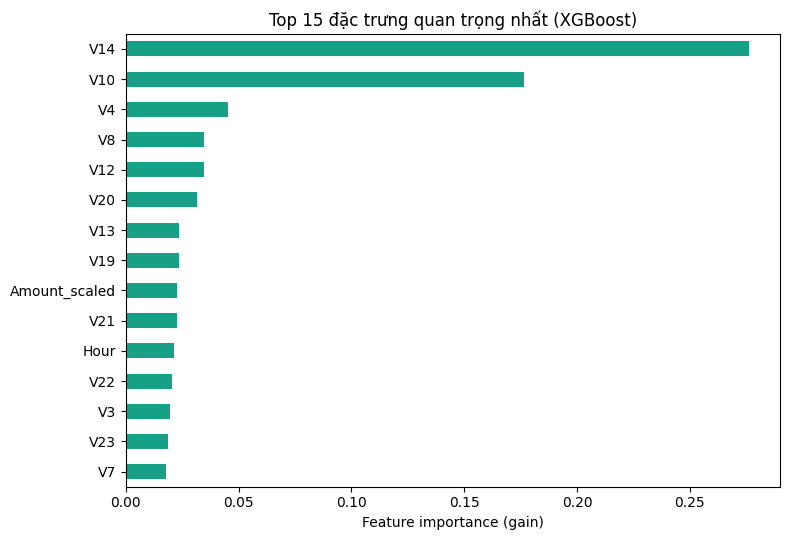

In [20]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5.5))
importances.iloc[::-1].plot.barh(ax=ax, color="#16a085")
ax.set_title("Top 15 đặc trưng quan trọng nhất (XGBoost)")
ax.set_xlabel("Feature importance (gain)")
fig.tight_layout()
plt.show()

`V14` và `V10` chiếm phần lớn tổng gain — hai thành phần PCA này gần
như luôn xuất hiện đầu bảng trong các phân tích công khai khác về cùng bộ dữ
liệu, dù không biết chúng đại diện cho biến gốc nào. `Amount_scaled` và
`Hour` — hai đặc trưng do chính notebook tạo ra — cũng lọt top nửa trên, cho
thấy bước feature engineering ở mục 2 có đóng góp thực chất, không chỉ mang
tính hình thức.

## Tổng kết

| Hạng mục | Kết quả |
| :--- | :--- |
| Chia dữ liệu | Theo THỜI GIAN (70/15/15), không shuffle |
| PR-AUC / ROC-AUC (XGBoost) | xem bảng so sánh mô hình ở trên |
| Ngưỡng đạt Precision ≥ 90% | xem mục 9 |
| Ngưỡng tối ưu theo chi phí | xem mục 10 |
| Độ trễ dự đoán 1 giao dịch | xem mục 11 — đối chiếu với yêu cầu < 100ms |
| Hạn chế | `V1`–`V28` đã PCA → không giải thích được theo nghiệp vụ |
| Giám sát drift | xem đề xuất trong `README.md` — mô phỏng train ngày 1 / test ngày 2 |

Số liệu đầy đủ (bảng so sánh mô hình, chi phí theo từng ngưỡng, tóm tắt JSON)
được lưu lại trong thư mục `../reports/` bởi `src/train.py` — notebook này
dùng để **giải thích lý do và cách đọc** từng bước, còn script dùng để tái
lập kết quả tự động.